# Parameter Estimation

This tutorial demonstrates how to estimate unknown model parameters from
experimental data using `discopt.estimate`. The estimation is formulated as
a weighted least-squares NLP and solved with discopt's NLP solvers, with
exact gradients and Hessians via JAX autodiff.

**Key concepts:**
- Define an `Experiment` that builds a discopt model with labeled unknowns and responses
- `estimate_parameters()` solves the weighted least-squares problem
- `EstimationResult` provides parameter estimates, covariance, confidence intervals, and the Fisher Information Matrix

For background on nonlinear parameter estimation, see {cite:p}`Bard1974` and {cite:p}`Biegler2010`.

In [1]:
import os

os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["JAX_ENABLE_X64"] = "1"

import discopt.modeling as dm
import matplotlib.pyplot as plt
import numpy as np
from discopt.estimate import Experiment, ExperimentModel, estimate_parameters

## 1. Simple curve fitting: exponential decay

Consider the model $y = A \exp(-k t)$ with unknown parameters $A$ (amplitude)
and $k$ (rate constant). We have noisy measurements at several time points.

Text(0.5, 1.0, 'Synthetic data')

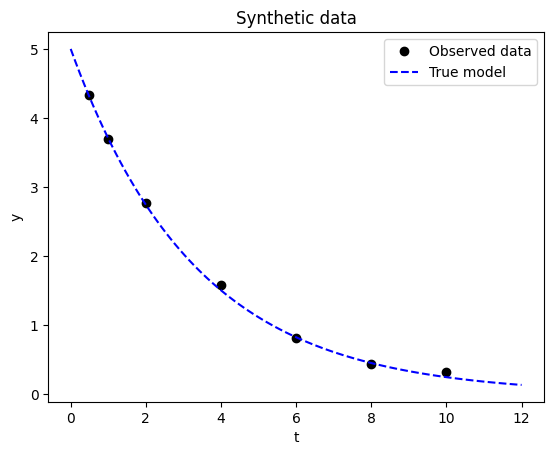

In [2]:
# Ground truth and synthetic data
A_true, k_true = 5.0, 0.3
t_data = np.array([0.5, 1.0, 2.0, 4.0, 6.0, 8.0, 10.0])
np.random.seed(42)
y_data = A_true * np.exp(-k_true * t_data) + 0.05 * np.random.randn(len(t_data))

plt.plot(t_data, y_data, "ko", label="Observed data")
t_fine = np.linspace(0, 12, 100)
plt.plot(t_fine, A_true * np.exp(-k_true * t_fine), "b--", label="True model")
plt.xlabel("t")
plt.ylabel("y")
plt.legend()
plt.title("Synthetic data")

### Define the Experiment

We subclass `Experiment` and implement `create_model()`. Unknown parameters
are modeled as `Variable` objects (what we optimize over). Responses are
model predictions at each measurement point.

In [3]:
class ExpDecayExperiment(Experiment):
    """y = A * exp(-k * t) at multiple time points."""

    def __init__(self, t_data):
        self.t_data = t_data

    def create_model(self, **kwargs):
        m = dm.Model("exp_decay")

        # Unknown parameters (modeled as Variables with bounds)
        A = m.continuous("A", lb=0.1, ub=20.0)
        k = m.continuous("k", lb=0.01, ub=5.0)

        # One response per measurement time
        responses = {}
        errors = {}
        for i, ti in enumerate(self.t_data):
            responses[f"y_{i}"] = A * dm.exp(-k * ti)
            errors[f"y_{i}"] = 0.05  # measurement std dev

        return ExperimentModel(
            model=m,
            unknown_parameters={"A": A, "k": k},
            design_inputs={},
            responses=responses,
            measurement_error=errors,
        )

### Run the estimation

In [4]:
exp = ExpDecayExperiment(t_data)
data = {f"y_{i}": y_data[i] for i in range(len(t_data))}

result = estimate_parameters(exp, data, initial_guess={"A": 3.0, "k": 0.5})
print(result.summary())


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



Parameter Estimation Results
             A =      4.99399  ± 0.0542  [4.855, 5.133]
             k =     0.293662  ± 0.006156  [0.2778, 0.3095]
     Objective = 3.79565
         N obs = 7
       FIM det = 1.844e+07
      FIM cond = 161.3


Text(0.5, 1.0, 'Parameter estimation result')

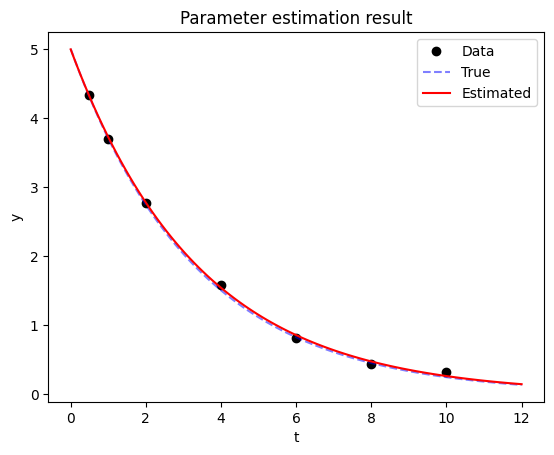

In [5]:
# Plot the fit
A_est = result.parameters["A"]
k_est = result.parameters["k"]

plt.plot(t_data, y_data, "ko", label="Data")
plt.plot(t_fine, A_true * np.exp(-k_true * t_fine), "b--", alpha=0.5, label="True")
plt.plot(t_fine, A_est * np.exp(-k_est * t_fine), "r-", label="Estimated")
plt.xlabel("t")
plt.ylabel("y")
plt.legend()
plt.title("Parameter estimation result")

### Inspect the results

The `EstimationResult` provides the Fisher Information Matrix (FIM),
parameter covariance ($\text{Cov}(\theta) \approx \text{FIM}^{-1}$),
confidence intervals, and a correlation matrix.

In [6]:
print("Confidence intervals (95%):")
for name, (lo, hi) in result.confidence_intervals.items():
    print(f"  {name}: [{lo:.4f}, {hi:.4f}]")

print(f"\nCorrelation matrix:\n{result.correlation_matrix}")
print(f"\nFIM:\n{result.fim}")

Confidence intervals (95%):
  A: [4.8547, 5.1333]
  k: [0.2778, 0.3095]

Correlation matrix:
[[1.         0.71620634]
 [0.71620634 1.        ]]

FIM:
[[  698.84378591 -4406.85273425]
 [-4406.85273425 54175.21502044]]


## 2. Linear regression (analytic verification)

For $y = a x + b$, the FIM has a known closed form:
$\text{FIM} = X^T \Sigma^{-1} X$ where $X = [\mathbf{x}, \mathbf{1}]$.
This lets us verify our implementation.

In [7]:
class LinearExperiment(Experiment):
    def __init__(self, x_data):
        self.x_data = x_data

    def create_model(self, **kwargs):
        m = dm.Model("linear")
        a = m.continuous("a", lb=-20, ub=20)
        b = m.continuous("b", lb=-20, ub=20)
        responses, errors = {}, {}
        for i, xi in enumerate(self.x_data):
            responses[f"y_{i}"] = a * xi + b
            errors[f"y_{i}"] = 0.1
        return ExperimentModel(
            model=m,
            unknown_parameters={"a": a, "b": b},
            design_inputs={},
            responses=responses,
            measurement_error=errors,
        )


x_data = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_data = 2.0 * x_data + 1.0  # exact data

exp = LinearExperiment(x_data)
data = {f"y_{i}": y_data[i] for i in range(len(x_data))}
result = estimate_parameters(exp, data)

# Compare FIM to analytic result
sigma = 0.1
X = np.column_stack([x_data, np.ones_like(x_data)])
fim_analytic = X.T @ X / sigma**2

print(f"Computed FIM:\n{result.fim}")
print(f"\nAnalytic FIM:\n{fim_analytic}")
print(f"\nMax difference: {np.max(np.abs(result.fim - fim_analytic)):.2e}")

Computed FIM:
[[5500. 1500.]
 [1500.  500.]]

Analytic FIM:
[[5500. 1500.]
 [1500.  500.]]

Max difference: 5.68e-14
